In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [43]:
df = pd.read_csv("secondary_ads_dataset.csv")

df.head()

,category,app_name,country,continent,review_id,review_date,rating,review_text,likes,reviewer_name,scraped_at,clean_text,ad_mentioned,ad_keyword,sentiment
0,Social Media,Instagram,us,North America,e3b1e0ac-69b8-4607-b76c-9847eeaf0e4e,2026-03-11 23:58:06,1,very nice app,0,KhushbooRani Khushboo,2026-03-13 00:02:03.924872,nice app,0,none,positive
1,Social Media,Instagram,us,North America,5157f955-0034-4dec-a286-848441463191,2026-03-11 23:58:02,5,Really helps getting to know other people's li...,0,Sena Risk,2026-03-13 00:02:03.924884,really help getting know people lifestyle ou,0,none,positive
2,Social Media,Instagram,us,North America,a53ce01c-3c11-4a43-a5b7-e20ef80b56f6,2026-03-11 23:57:48,5,this one,0,Ankit Saini,2026-03-13 00:02:03.924886,one,0,none,neutral
3,Social Media,Instagram,us,North America,454407b1-e1a6-4f9b-8485-39ffa412b563,2026-03-11 23:56:29,1,not good for use..,0,Pavan Bidve,2026-03-13 00:02:03.924888,good use,0,none,positive
4,Social Media,Instagram,us,North America,262f9eec-8c03-4728-8d7b-03d38008182f,2026-03-11 23:56:10,5,very good 💯 👌🏻👍🏻,0,vandana kashyap,2026-03-13 00:02:03.924890,good,0,none,positive


In [44]:
df["review_date"] = pd.to_datetime(df["review_date"])

In [45]:
df["review_date"] = df["review_date"].dt.date

In [46]:
sentiment_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

df["sentiment_score"] = df["sentiment"].map(sentiment_map)

In [47]:
daily_df = df.groupby("review_date").agg(
    y=("ad_mentioned","sum"),
    sentiment_avg=("sentiment_score","mean")
).reset_index()

In [48]:
daily_df.rename(columns={"review_date":"ds"}, inplace=True)

daily_df.head()

,ds,y,sentiment_avg
0,2024-06-22,22,0.000000
1,2024-06-23,11,-1.000000
2,2024-06-25,11,0.666667
3,2024-06-26,22,0.000000
4,2024-06-27,0,-1.000000


In [49]:
daily_df["y"].describe()

,y
count,514.000000
mean,77.282101
std,574.480140
min,0.000000
25%,0.000000
50%,11.000000
75%,22.000000
max,11245.000000


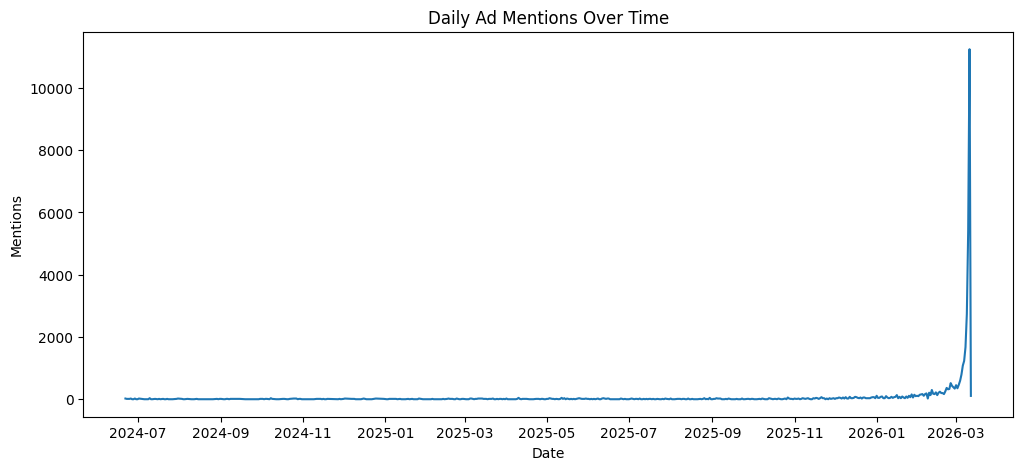

In [50]:
plt.figure(figsize=(12,5))

plt.plot(daily_df["ds"], daily_df["y"])

plt.title("Daily Ad Mentions Over Time")
plt.xlabel("Date")
plt.ylabel("Mentions")

plt.show()

In [9]:
!pip install prophet

In [51]:
full_dates = pd.date_range(
    start=daily_df.ds.min(),
    end=daily_df.ds.max()
)

daily_df = daily_df.set_index("ds").reindex(full_dates).fillna(0)

daily_df = daily_df.rename_axis("ds").reset_index()

In [67]:
daily_df.sort_values("y", ascending=False).head(10)

,ds,y,sentiment_avg
612,2026-02-24,330.0,0.571429
611,2026-02-23,319.0,0.449664
599,2026-02-11,297.0,0.477273
609,2026-02-21,253.0,0.496241
605,2026-02-17,242.0,0.638889
602,2026-02-14,220.0,0.431818
604,2026-02-16,209.0,0.473684
597,2026-02-09,209.0,0.301205
607,2026-02-19,198.0,0.478261
606,2026-02-18,198.0,0.565217


In [68]:
threshold = daily_df["y"].quantile(0.99)

daily_df = daily_df[daily_df["y"] <= threshold]

In [69]:
train = daily_df[:-30]
test = daily_df[-30:]

In [70]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [71]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-06-22,18.196612,-12.196106,16.668939,18.196612,18.196612,-15.802835,-15.802835,-15.802835,-14.925464,-14.925464,-14.925464,-0.877372,-0.877372,-0.877372,0.0,0.0,0.0,2.393776
1,2024-06-23,18.207306,-12.309273,18.627400,18.207306,18.207306,-15.093347,-15.093347,-15.093347,-14.925464,-14.925464,-14.925464,-0.167883,-0.167883,-0.167883,0.0,0.0,0.0,3.113959
2,2024-06-24,18.218000,-10.097475,17.660514,18.218000,18.218000,-14.785983,-14.785983,-14.785983,-14.925464,-14.925464,-14.925464,0.139481,0.139481,0.139481,0.0,0.0,0.0,3.432017
3,2024-06-25,18.228694,-10.927267,16.923869,18.228694,18.228694,-14.460775,-14.460775,-14.460775,-14.925464,-14.925464,-14.925464,0.464689,0.464689,0.464689,0.0,0.0,0.0,3.767919
4,2024-06-26,18.239388,-10.517318,16.694213,18.239388,18.239388,-15.640225,-15.640225,-15.640225,-14.925464,-14.925464,-14.925464,-0.714761,-0.714761,-0.714761,0.0,0.0,0.0,2.599163


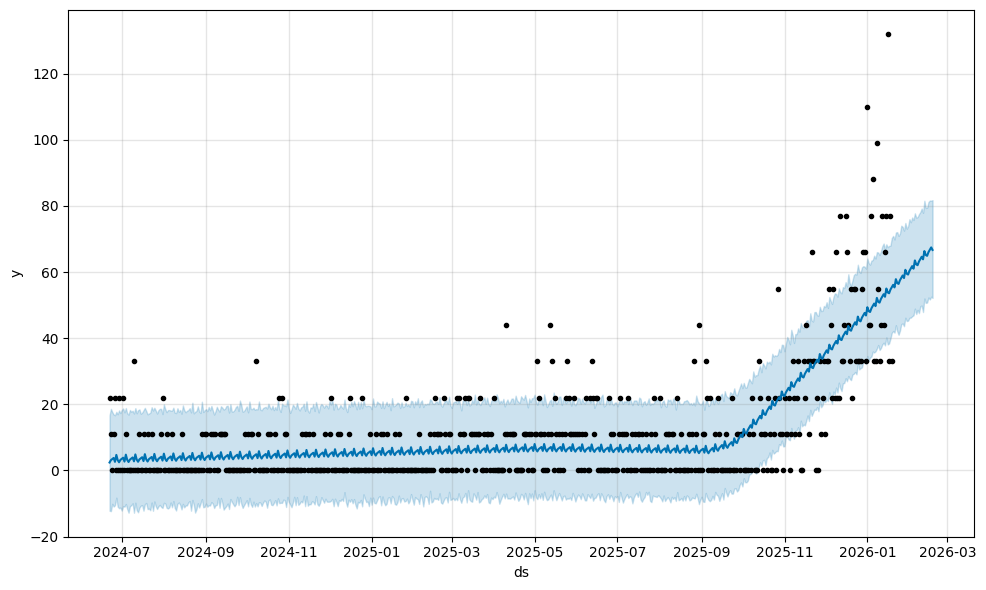

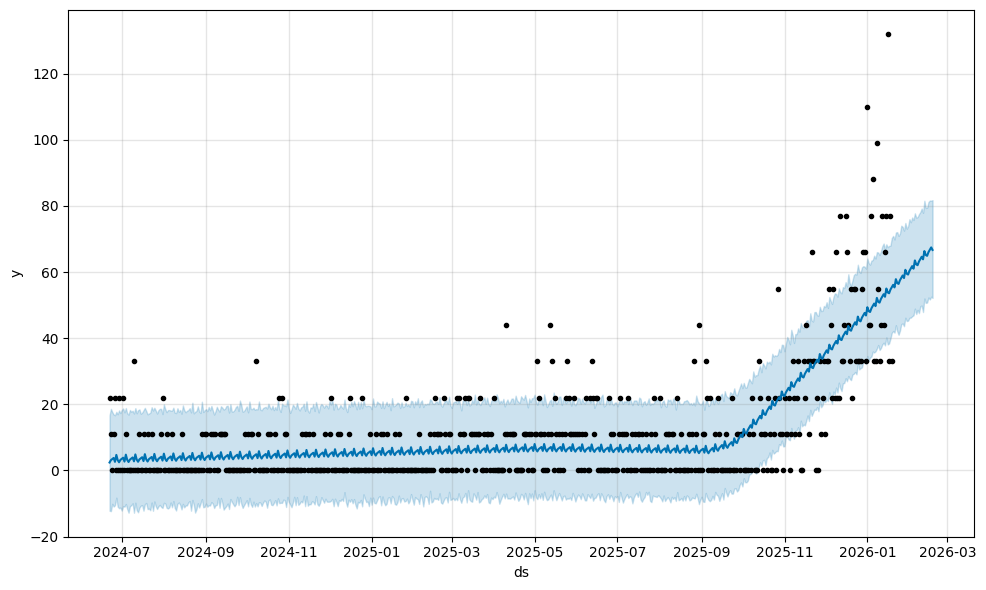

In [72]:
model.plot(forecast)

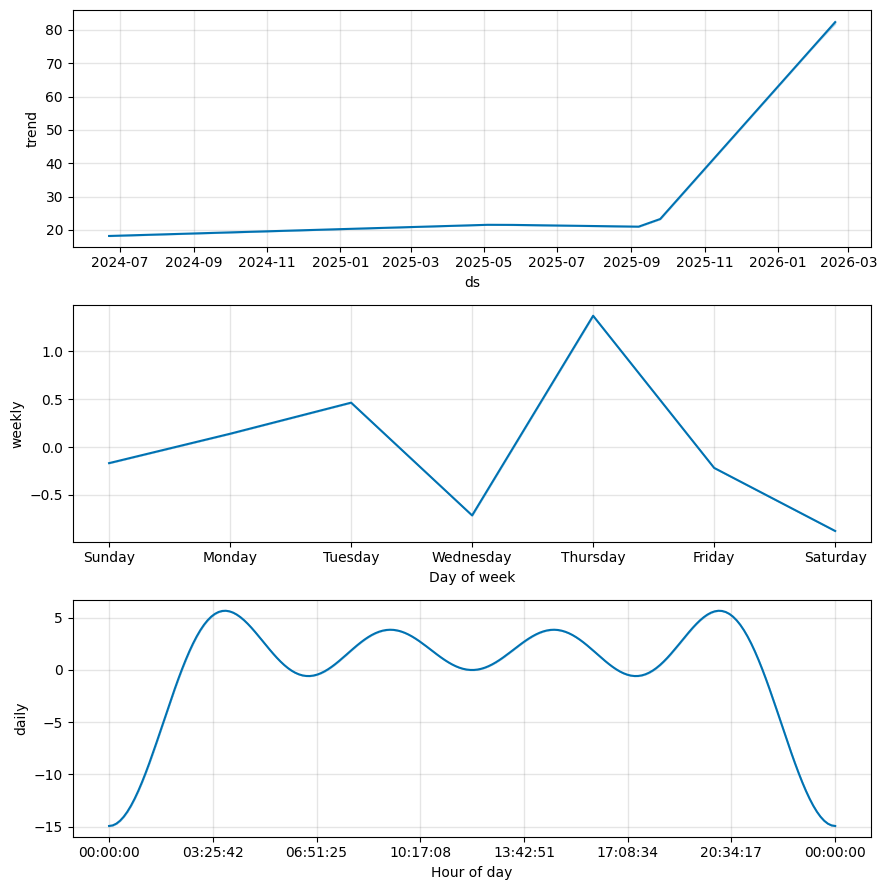

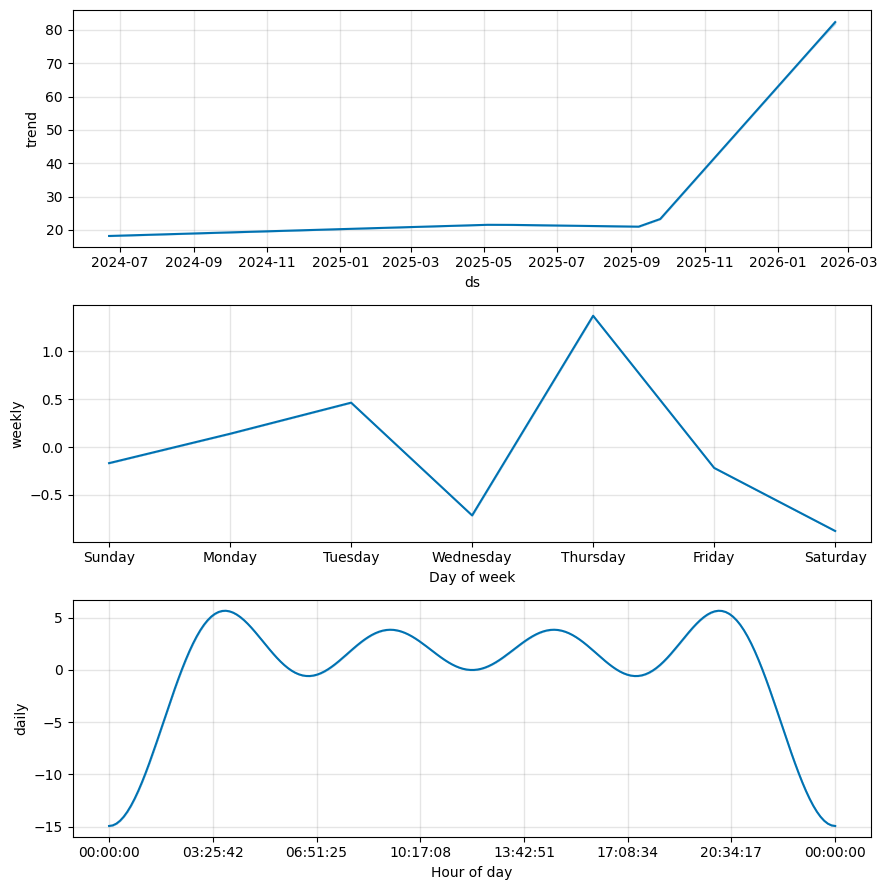

In [73]:
model.plot_components(forecast)

In [74]:
daily_df["y"].describe()

,y
count,607.000000
mean,16.467875
std,32.294160
min,0.000000
25%,0.000000
50%,11.000000
75%,22.000000
max,209.000000


In [78]:
forecast_test = forecast[['ds','yhat']].merge(
    test[['ds','y']],
    on='ds',
    how='inner'
)

mae = mean_absolute_error(forecast_test["y"], forecast_test["yhat"])
rmse = np.sqrt(mean_squared_error(forecast_test["y"], forecast_test["yhat"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 67.61534122338354
RMSE: 79.9357293741329


In [79]:
forecast_next_month = forecast.tail(30)["yhat"].sum()

print("Forecasted Ad Mentions (Next 30 Days):", forecast_next_month)

Forecasted Ad Mentions (Next 30 Days): 1845.4728561000395


In [80]:
forecast.to_csv("ad_mentions_forecast.csv", index=False)

In [81]:
df["ad_mentioned"].value_counts()

df["ad_mentioned"].sum()

np.int64(39723)

In [82]:
avg_sentiment = daily_df["sentiment_avg"].mean()

print("Average Sentiment:", avg_sentiment)

Average Sentiment: 0.30762682681708725
